In [42]:
%load_ext autoreload
%autoreload 2

import sys, importlib, shutil
from pathlib import Path
from qiskit.visualization import plot_histogram
import numpy as np

workspace_root = str(Path.cwd().parent)
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Clear stale bytecode cache
shutil.rmtree(Path(workspace_root) / 'utils/__pycache__', ignore_errors=True)


# Force-reload modules so kernel picks up any source changes
import utils.arithmetic, utils.sto_1s_1d, utils.sto_1s_3d, utils.sto_2s_3d, utils.integrals, utils.simulation_excutor, utils.sample_interpreter
import utils.noisy_sampler_executor, utils.noisy_estimator_executor, utils.resource_estimator
importlib.reload(utils.arithmetic)
importlib.reload(utils.sto_1s_1d)
importlib.reload(utils.sto_1s_3d)
importlib.reload(utils.sto_2s_3d)
importlib.reload(utils.integrals)
importlib.reload(utils.simulation_excutor)
importlib.reload(utils.sample_interpreter)
importlib.reload(utils.noisy_sampler_executor)
importlib.reload(utils.noisy_estimator_executor)
importlib.reload(utils.resource_estimator)

from utils.simulation_excutor import SimulationExecutor
from utils.sample_interpreter import SampleInterpreter
from utils.noisy_sampler_executor import NoisySamplerExecutor
from utils.noisy_estimator_executor import NoisyEstimatorExecutor
from utils.resource_estimator import ResourceEstimator

allow_measurement=False
optimize_t_gates=True

simulation_executor = SimulationExecutor()
sample_interpreter = SampleInterpreter()
noisy_simlutation_executor = NoisySamplerExecutor(enable_dd=(not allow_measurement), enable_twirling=True, enable_m3=True)
noisy_estimator_executor = NoisyEstimatorExecutor(enable_dd=(not allow_measurement),
                                                  enable_twirling=True,
                                                  enable_measure_mitigation=True,
                                                  enable_zne=True,
                                                  zne_noise_factors=[1, 3, 5, 7])
resource_estimator = ResourceEstimator()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


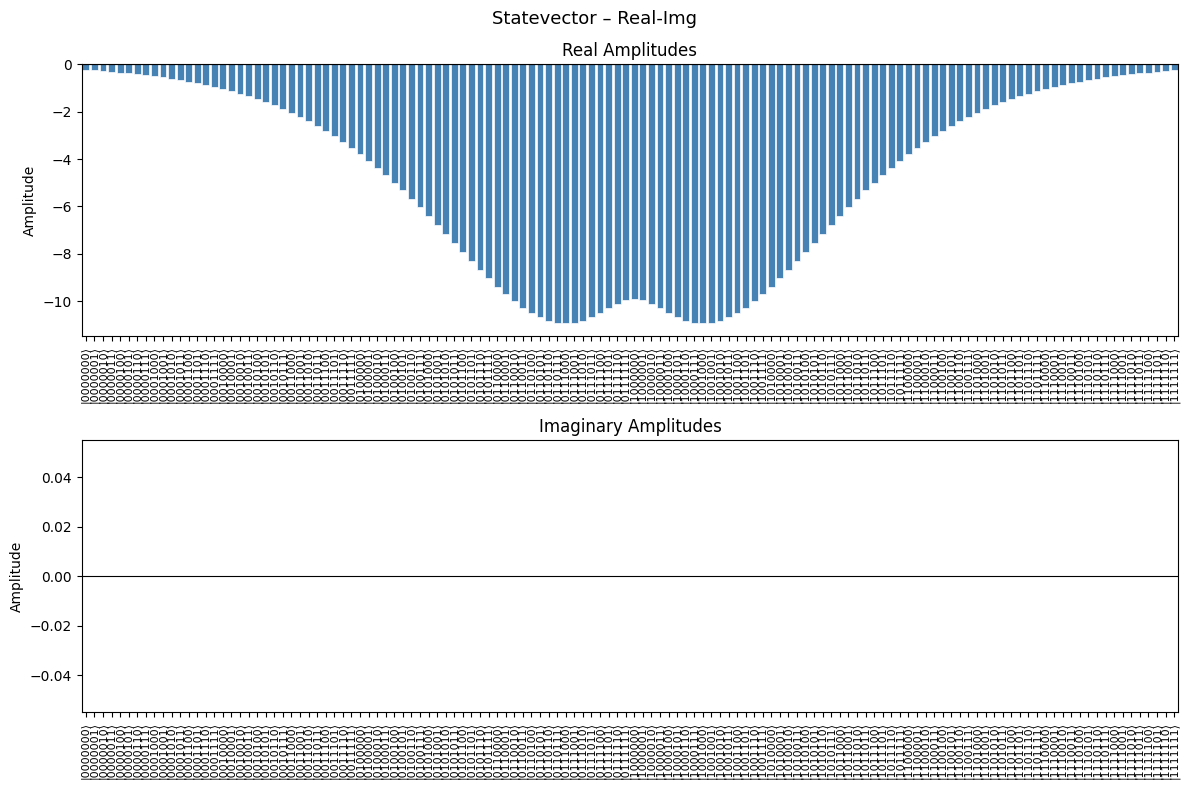

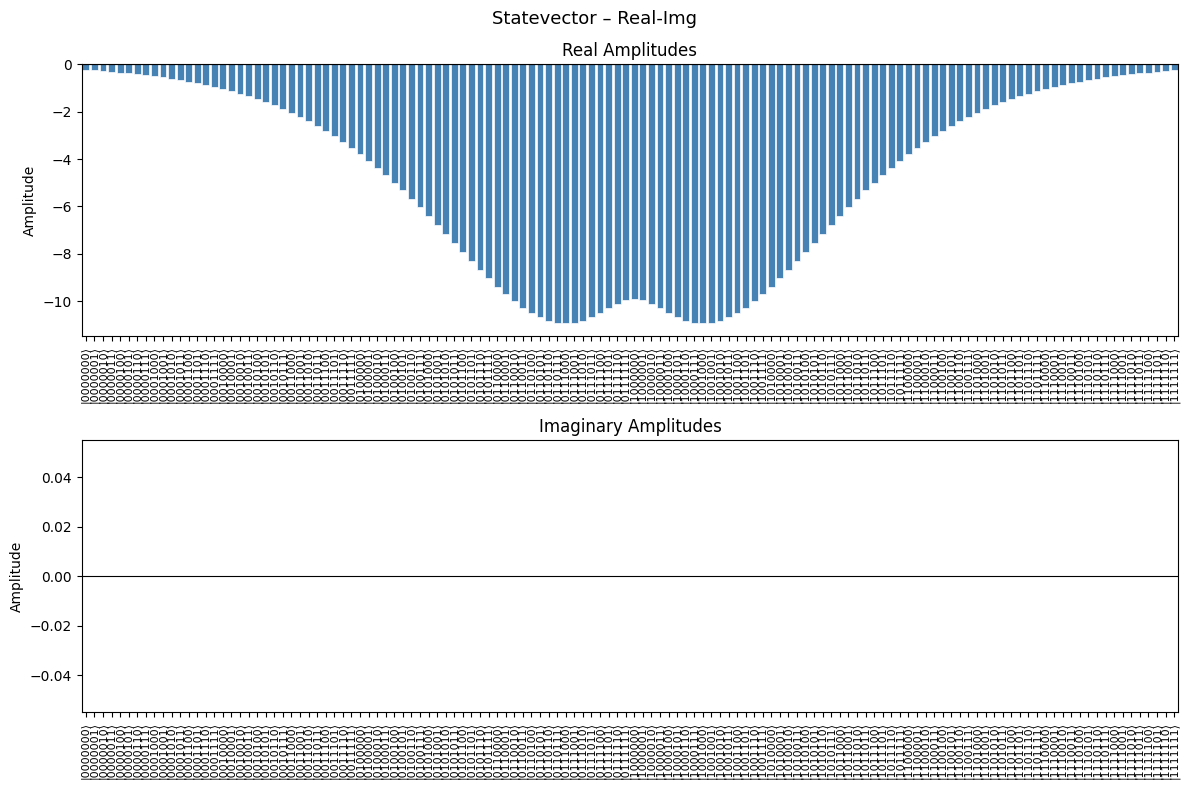

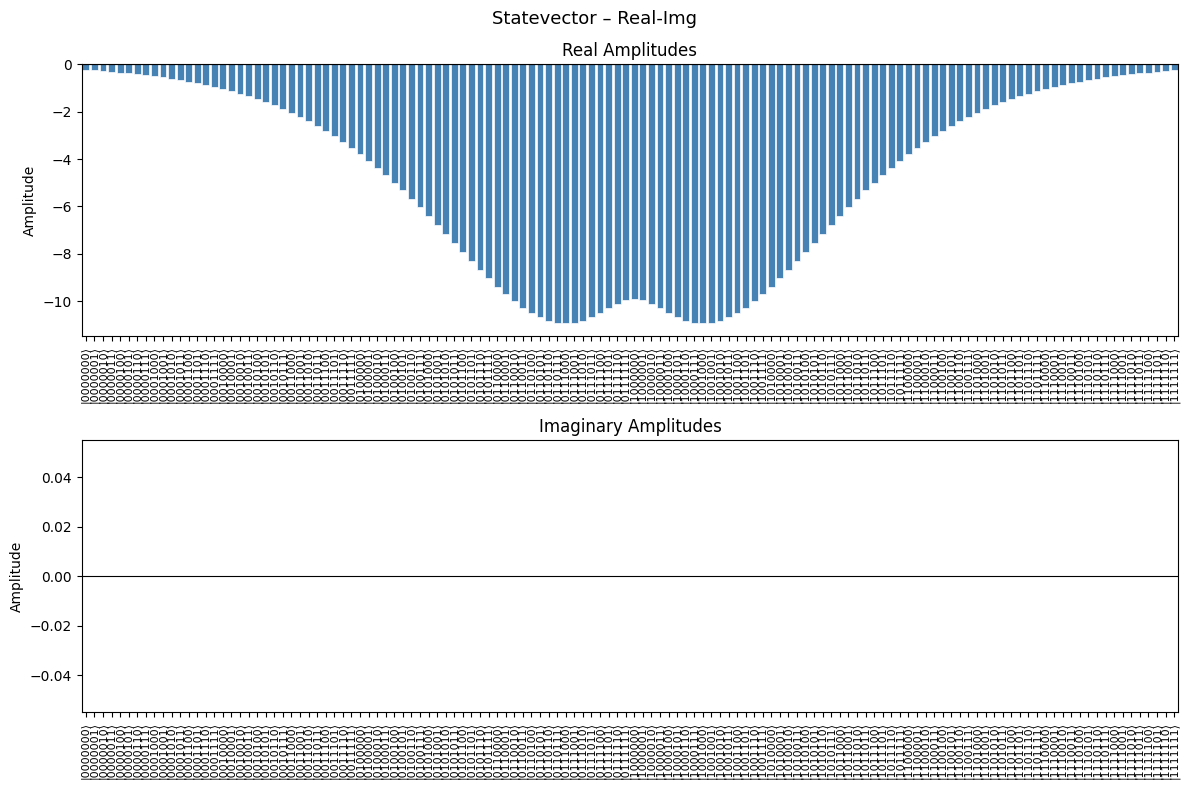

In [57]:

a = 1  # decay constant
qubits_per_coordinate = 7
max_range_per_coordinate = 32
center_distance = 1.4
total_qubits = 3 * qubits_per_coordinate

scale = (2 ** qubits_per_coordinate) / max_range_per_coordinate
scaled_center_distance = round(center_distance * scale)
scaled_a = a #/ scale

used_center_distance = scaled_center_distance / scale

# center1 = 2 ** (3 * qubits_per_coordinate - 1)
# center2 = 2 ** (3 * qubits_per_coordinate - 1) + scaled_center_distance

# print(f"qubit count={3 * qubits_per_coordinate}")
# print(f"center2={center2}")

from utils.circuit_handler import CircuitHandler
from utils.sto_1s_3d import Sto1S3D
sto1s3d = Sto1S3D()
from utils.sto_2s_3d import Sto2S3D
sto2s3d = Sto2S3D()

# qc = sto1s3d.sto_1s_3d_cartesian(qubits_per_coordinate, scaled_a)
# qc = sto1s3d.sto_1s_3d_cartesian_bounded(qubits_per_coordinate, scaled_a, max_range_per_coordinate)

# qc = sto2s3d.sto_2s_3d_cartesian(qubits_per_coordinate, scaled_a)
qc = sto2s3d.sto_2s_3d_cartesian_bounded(qubits_per_coordinate, scaled_a, max_range_per_coordinate)

# display(qc.draw('mpl'))

data_amps = simulation_executor.get_data_amplitudes(qc, total_qubits)
x_marginal, y_marginal, z_marginal = sample_interpreter.split_run_results_by_coordinate(qubits_per_coordinate, data_amps)

fig = simulation_executor.plot_statevector_real_imag(x_marginal, qubits_per_coordinate)
fig = simulation_executor.plot_statevector_real_imag(y_marginal, qubits_per_coordinate)
fig = simulation_executor.plot_statevector_real_imag(z_marginal, qubits_per_coordinate)
